In [1]:
from capture_utils_v2 import CaptureSystem

# Initialize the capture system
system = CaptureSystem()


Pixel format set to RGB8
IC4 Grabber and Sink initialized.


4/5 marker corners detected.
[[ 3]
 [ 3]
 [10]]


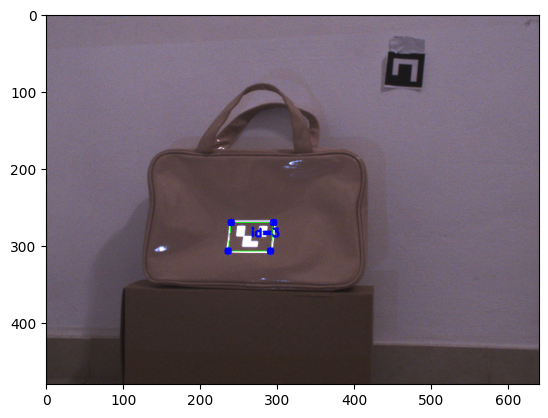

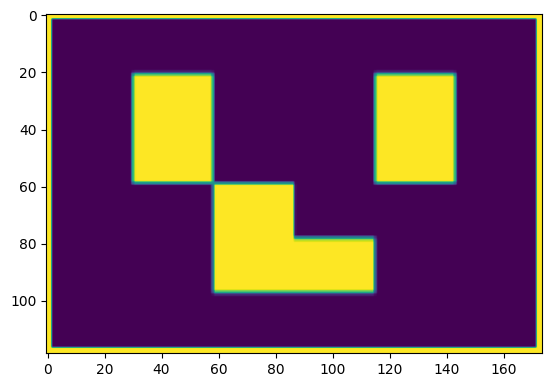

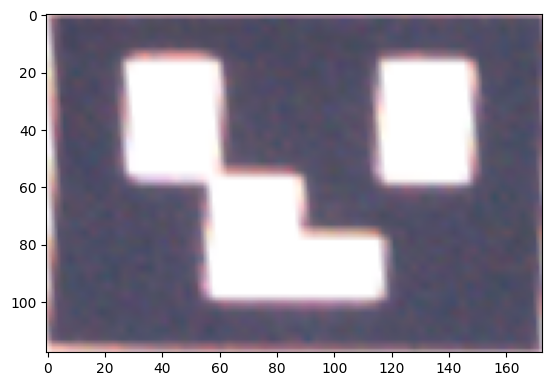

In [2]:
system.display_drawer()
system.run_aruco_detector()


In [3]:
ret = system.photometric_calibration(return_captured=True)
# system.photometric_calibration_adaptive()

100%|██████████| 33/33 [01:01<00:00,  1.86s/it]


In [4]:
# save system orig_proj_corners and corners_img_proj to a file
import pickle
with open("capture_system_state.pkl", "wb") as f:
    pickle.dump({'orig_proj_corners': system.orig_proj_corners,
                  'corners_img_proj': system.corners_img_proj, 
                  'orig_img': system.orig_img, 
                  'img_non_zero_section': system.img_non_zero_section, 
                  'H': system.H
                  }, f)

## Infer

In [ ]:
# for capaa
import sys
sys.path.append(r'C:\git\CAPAA\src\python')
from utils import init_prj_window

c:\Users\danny\anaconda3\envs\py310\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
from capture_utils_v2 import CaptureSystem
import cv2
import pickle
from aruco_pose import get_camera_angles_from_frame
# Initialize the capture system
system = CaptureSystem()


In [ ]:
# im_path = './results/best_patch_ensamble_classifier_16x16_16_2025-12-24_10_08.png'
im_path = './results/best_patch_ensamble_classifier_16x16_7_2025-12-24_23_19.png'
image_to_project =  cv2.imread(im_path)
image_to_project = cv2.cvtColor(image_to_project, cv2.COLOR_BGR2RGB)

In [ ]:
import pickle
with open("capture_system_state.pkl", "rb") as f:
    system_dict = pickle.load(f)

system.orig_proj_corners, system.corners_img_proj, system.orig_img, system.img_non_zero_section \
    = system_dict['orig_proj_corners'], system_dict['corners_img_proj'],system_dict['orig_img'], system_dict['img_non_zero_section']

In [ ]:
system.plot_on_screen(image_to_project)

In [ ]:
#capaa
# from omegaconf import DictConfig, OmegaConf
# import matplotlib as plt
# plt.use('Qt5Agg')
# p = r"C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all\img_0001.png"
# img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
# setup_info = DictConfig(dict(
#     prj_screen_sz      = (1920 , 1080),   # projector screen resolution (i.e., set in the OS)
#     prj_im_sz          = (256 , 256),   # projector input image resolution, the image will be scaled to match the prj_screen_sz by plt
#     prj_offset         = (2560,   0),   # an offset to move the projector plt figure to the correct screen (check your OS display setting)
#     prj_brightness     = 0.5,           # brightness (0~1 float) of the projector gray image for scene illumination.

#     # adjust the two params below according to your ProCams latency, until the projected and captured numbers images are correctly matched
#     delay_frames = 5,  # how many frames to drop before we capture the correct one, increase it when ProCams are not in sync
#     delay_time = 0.1,  # a delay time (s) between the project and capture operations for software sync, increase it when ProCams are not in sync
#     )
# )
# prj = init_prj_window(*setup_info['prj_screen_sz'], 0.5, setup_info['prj_offset'])
# prj.set_data(img)

In [ ]:
import torch
# from classfier import predict_raw, weights
# from classfier_ensemble import predict_raw, weights
from classfier_ensemble_v2 import predict_raw, weights
# from classfier_dino import predict_raw, weights

In [ ]:
weights.meta['categories'].index('backpack')

In [ ]:


tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()
cap = system.cap

caps = []
caps_with_text = []
results = []
for i in range(2400):
    r = cap.read()[1]
    tr = tt(r)
    with torch.no_grad():
        p = predict_raw(tr.unsqueeze(0).cuda())
        res = weights.meta["categories"][p[0].argmax(0).item()]
        prob = p[0].max(0).values.item() * 100
    
    # add text
    r_orig = r.copy()
    pose_result = get_camera_angles_from_frame(r)
    cv2.putText(r, f'Pred: {res}: {prob:.2f}%', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    
    # Display camera angles if ArUco marker is detected
    if pose_result['found']:
        angle = pose_result['angle']
        dist = pose_result['distance_m']
        cv2.putText(r, f'H: {angle:.1f}deg  Dist: {dist:.1f}m', (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    else:
        cv2.putText(r, 'ArUco not detected', (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    
    cv2.imshow('frame', r)
    results.append(res)

    caps_with_text.append(r)
    caps.append(r_orig)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        raise

In [ ]:
# save caps to disk

In [ ]:
import os
import datetime
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
infer_caps_dir = r"C:\git\PhysicalAdverserialProj\infer_caps_dir"
exp_name = rf"{os.path.basename(im_path).split('.')[0]}"
# exp_name = "capaa_jeep8_5_1"
os.makedirs(f"{infer_caps_dir}/{exp_name}/{cur_time}/")
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/caps.pkl", "wb") as f:
    pickle.dump(caps, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/caps_with_text.pkl", "wb") as f:
    pickle.dump(caps_with_text, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/results.pkl", "wb") as f:
    pickle.dump(results, f)

### With tracking

In [ ]:
# from classfier import *
# from tracking_utils import TrackerSystem
# image_to_project =  patch = cv2.imread(r'C:\git\PhysicalAdverserialProj\results\best_patch_16x16_1_2025-12-13_16_22.png')

# tracker = TrackerSystem(system, predict_raw, weights, printed_aruco_id=10)
# caps, results = tracker.track_project_and_classify(image_to_project)

## Create GIF

In [ ]:
import imageio

captures = caps
# Create GIF from captures
captures_rgb = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in captures]
output_gif_path = 'tracked_jeep_16x16_1_2025-12-13_16_22_inception_v3.gif'
imageio.mimsave(output_gif_path, captures_rgb, fps=14, loop=0)
print(f"GIF saved to {output_gif_path} with {len(captures)} frames")

In [ ]:
#

## Post capture analysis

In [ ]:
# Setup for analysis
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import pickle
import importlib

# Import orig_clases - vehicle classes we want to avoid
import consts
importlib.reload(consts)
orig_clases = consts.orig_clases

from aruco_pose import get_camera_angles_from_frame

# Load camera calibration for ArUco detection
cameraMatrix, dist_coeffs = pickle.load(open(r"C:\git\wall_alignment\calibration.pkl", "rb"))

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

print(f"Original vehicle classes to avoid: {orig_clases.tolist()}")
print(f"Number of captured frames: {len(caps)}")

In [ ]:
# Load all classifiers for evaluation
print("Loading classifiers...")

# Ensemble v1 classifier (Inception, ResNet, VGG, ViT, DINOv2)
import classfier_ensemble as ensemble_v1
ensemble_v1_weights = ensemble_v1.weights
print("✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)")

# Ensemble v2 classifier (ConvNeXt, EfficientNet, MobileNet, Swin)
import classfier_ensemble_v2 as ensemble_v2
ensemble_v2_weights = ensemble_v2.weights
print("✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)")

# DINOv2 standalone classifier
import classfier_dino as dino
dino_weights = dino.weights
print("✓ DINOv2 standalone classifier loaded")

categories = ensemble_v1_weights.meta["categories"]
print(f"\n✓ All classifiers ready for evaluation")

In [ ]:
# Analyze all captured frames - extract pose info and classify with all models
results_list = []

for frame_idx, frame in enumerate(tqdm(caps, desc="Analyzing frames")):
    # Get ArUco pose (angle and distance)
    pose_result = get_camera_angles_from_frame(frame)
    
    if not pose_result['found']:
        continue  # Skip frames without ArUco marker
    
    angle = pose_result['angle']
    distance = pose_result['distance_m']
    
    # Prepare image tensor
    img_tensor = tt(frame).unsqueeze(0).cuda()
    
    with torch.no_grad():
        # Get predictions from each model in ensemble v1
        ensemble_v1_per_model = ensemble_v1.predict_raw_per_model(img_tensor)
        
        # Get predictions from each model in ensemble v2
        ensemble_v2_per_model = ensemble_v2.predict_raw_per_model(img_tensor)
        
        # Get DINOv2 standalone prediction
        dino_probs = dino.predict_raw(img_tensor)
    
    # Build result row
    result_row = {
        'frame_idx': frame_idx,
        'angle_deg': angle,
        'distance_m': distance,
    }
    
    # Process ensemble v1 models (individual) - Inception, ResNet, VGG, ViT, DINOv2
    for model_name in ['inception', 'resnet', 'vgg', 'vit', 'dino']:
        if model_name in ensemble_v1_per_model:
            probs = ensemble_v1_per_model[model_name]
            pred_idx = probs[0].argmax().item()
            pred_conf = probs[0][pred_idx].item()
            pred_class = categories[pred_idx]
            
            # Check if attack is successful (prediction NOT in orig_clases)
            is_success = pred_idx not in orig_clases.tolist()
            
            result_row[f'v1_{model_name}_class'] = pred_class
            result_row[f'v1_{model_name}_idx'] = pred_idx
            result_row[f'v1_{model_name}_conf'] = pred_conf
            result_row[f'v1_{model_name}_success'] = is_success
    
    # Ensemble v1 combined prediction
    if 'ensemble' in ensemble_v1_per_model:
        ens_probs = ensemble_v1_per_model['ensemble']
        ens_pred_idx = ens_probs[0].argmax().item()
        ens_pred_conf = ens_probs[0][ens_pred_idx].item()
        ens_pred_class = categories[ens_pred_idx]
        ens_is_success = ens_pred_idx not in orig_clases.tolist()
        
        result_row['v1_combined_class'] = ens_pred_class
        result_row['v1_combined_idx'] = ens_pred_idx
        result_row['v1_combined_conf'] = ens_pred_conf
        result_row['v1_combined_success'] = ens_is_success
    
    # Process ensemble v2 models (individual) - ConvNeXt, EfficientNet, MobileNet, Swin
    for model_name in ['convnext', 'efficientnet', 'mobilenet', 'swin']:
        if model_name in ensemble_v2_per_model:
            probs = ensemble_v2_per_model[model_name]
            pred_idx = probs[0].argmax().item()
            pred_conf = probs[0][pred_idx].item()
            pred_class = categories[pred_idx]
            
            # Check if attack is successful (prediction NOT in orig_clases)
            is_success = pred_idx not in orig_clases.tolist()
            
            result_row[f'v2_{model_name}_class'] = pred_class
            result_row[f'v2_{model_name}_idx'] = pred_idx
            result_row[f'v2_{model_name}_conf'] = pred_conf
            result_row[f'v2_{model_name}_success'] = is_success
    
    # Ensemble v2 combined prediction
    if 'ensemble' in ensemble_v2_per_model:
        ens_probs = ensemble_v2_per_model['ensemble']
        ens_pred_idx = ens_probs[0].argmax().item()
        ens_pred_conf = ens_probs[0][ens_pred_idx].item()
        ens_pred_class = categories[ens_pred_idx]
        ens_is_success = ens_pred_idx not in orig_clases.tolist()
        
        result_row['v2_combined_class'] = ens_pred_class
        result_row['v2_combined_idx'] = ens_pred_idx
        result_row['v2_combined_conf'] = ens_pred_conf
        result_row['v2_combined_success'] = ens_is_success
    
    # DINOv2 standalone
    dino_pred_idx = dino_probs[0].argmax().item()
    dino_pred_conf = dino_probs[0][dino_pred_idx].item()
    dino_pred_class = categories[dino_pred_idx]
    dino_is_success = dino_pred_idx not in orig_clases.tolist()
    
    result_row['dino_standalone_class'] = dino_pred_class
    result_row['dino_standalone_idx'] = dino_pred_idx
    result_row['dino_standalone_conf'] = dino_pred_conf
    result_row['dino_standalone_success'] = dino_is_success
    
    results_list.append(result_row)

print(f"\n✓ Analyzed {len(results_list)} frames with ArUco marker detected")
df = pd.DataFrame(results_list)

In [ ]:
%matplotlib inline

In [ ]:
# Calculate and display success rates per model with clear v1/v2/dino distinction
print("="*80)
print("ATTACK SUCCESS RATE ANALYSIS")
print("="*80)
print(f"\nSuccess = classifier output NOT in orig_clases (vehicle classes)")
print(f"Total frames analyzed: {len(df)}")
print(f"Angle range: {df['angle_deg'].min():.1f}° to {df['angle_deg'].max():.1f}°")
print(f"Distance range: {df['distance_m'].min():.2f}m to {df['distance_m'].max():.2f}m")

# Get all success columns
success_cols = [c for c in df.columns if c.endswith('_success')]

# Define model groups for clear display - DINOv2 standalone only
v1_models = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined']
dino_models = ['dino_standalone']  # Only standalone DINOv2
v2_models = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin', 'v2_combined']

# Display names mapping
display_names = {
    'v1_inception': 'Inception V3',
    'v1_resnet': 'ResNet18',
    'v1_vgg': 'VGG16',
    'v1_vit': 'ViT-B/16',
    'v1_combined': '*** COMBINED ***',
    'v2_convnext': 'ConvNeXt Base',
    'v2_efficientnet': 'EfficientNet B0',
    'v2_mobilenet': 'MobileNetV3 Large',
    'v2_swin': 'Swin Transformer',
    'v2_combined': '*** COMBINED ***',
    'dino_standalone': 'DINOv2',
}

success_summary = []

def print_model_results(model_list, df, success_summary, group_name):
    for model_name in model_list:
        success_col = f'{model_name}_success'
        if success_col in df.columns:
            success_count = df[success_col].sum()
            total_count = len(df)
            success_rate = success_count / total_count * 100
            
            display = display_names.get(model_name, model_name)
            print(f"  {display:<25} {success_rate:>10.1f}% {success_count:>10} / {total_count:<8}")
            
            success_summary.append({
                'Model': display,
                'Group': group_name,
                'Success Rate (%)': success_rate,
                'Successful Attacks': int(success_count),
                'Total Frames': total_count
            })

# Print Ensemble v1 results
print(f"\n{'─'*80}")
print("ENSEMBLE V1 (Inception V3, ResNet18, VGG16, ViT-B/16)")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(v1_models, df, success_summary, 'V1')

# Print DINOv2 results (standalone only)
print(f"\n{'─'*80}")
print("DINOv2 CLASSIFIER")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(dino_models, df, success_summary, 'DINOv2')

# Print Ensemble v2 results
print(f"\n{'─'*80}")
print("ENSEMBLE V2 (ConvNeXt, EfficientNet, MobileNet, Swin Transformer)")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(v2_models, df, success_summary, 'V2')

success_df = pd.DataFrame(success_summary)
print("\n" + "="*80)

In [ ]:
# Visualize success rate vs angle and distance
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Create angle bins for analysis
angle_bins = np.linspace(df['angle_deg'].min(), df['angle_deg'].max(), 11)
df['angle_bin'] = pd.cut(df['angle_deg'], bins=angle_bins)

# Create distance bins for analysis
distance_bins = np.linspace(df['distance_m'].min(), df['distance_m'].max(), 6)
df['distance_bin'] = pd.cut(df['distance_m'], bins=distance_bins)

# Compute angle_mids once for reuse
angle_success_v1 = df.groupby('angle_bin', observed=False)['v1_combined_success'].agg(['mean', 'count'])
angle_mids = [(b.left + b.right)/2 for b in angle_success_v1.index]

# 1. Overall success rate bar chart
ax = axes[0, 0]
colors = ['green' if r > 50 else 'orange' if r > 25 else 'red' for r in success_df['Success Rate (%)']]
bars = ax.barh(success_df['Model'], success_df['Success Rate (%)'], color=colors)
ax.set_xlabel('Success Rate (%)')
ax.set_title('Attack Success Rate by Model')
ax.set_xlim(0, 100)
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
for i, (bar, rate) in enumerate(zip(bars, success_df['Success Rate (%)'])):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center')

# 2. Success rate vs Angle (V1 ensemble combined)
ax = axes[0, 1]
angle_success_v1['mean'] = angle_success_v1['mean'] * 100
ax.bar(range(len(angle_mids)), angle_success_v1['mean'], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(angle_mids)))
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('V1 Combined: Success Rate vs Angle')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 3. Success rate vs Distance (V1 ensemble combined)
ax = axes[0, 2]
dist_success = df.groupby('distance_bin', observed=False)['v1_combined_success'].agg(['mean', 'count'])
dist_success['mean'] = dist_success['mean'] * 100
dist_mids = [(b.left + b.right)/2 for b in dist_success.index]
ax.bar(range(len(dist_mids)), dist_success['mean'], color='darkorange', alpha=0.7)
ax.set_xticks(range(len(dist_mids)))
ax.set_xticklabels([f'{d:.2f}m' for d in dist_mids], rotation=45)
ax.set_xlabel('Distance (meters)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('V1 Combined: Success Rate vs Distance')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 4. Scatter plot: Angle vs Distance colored by success (V1 ensemble)
ax = axes[1, 0]
colors_scatter = ['green' if s else 'red' for s in df['v1_combined_success']]
ax.scatter(df['angle_deg'], df['distance_m'], c=colors_scatter, alpha=0.5, s=20)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Distance (meters)')
ax.set_title('V1 Combined: Success Distribution\n(Green=Success, Red=Fail)')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# 5. Success rate vs Angle for DINOv2 standalone
ax = axes[1, 1]
angle_success_dino = df.groupby('angle_bin', observed=False)['dino_standalone_success'].agg(['mean', 'count'])
angle_success_dino['mean'] = angle_success_dino['mean'] * 100
ax.bar(range(len(angle_mids)), angle_success_dino['mean'], color='purple', alpha=0.7)
ax.set_xticks(range(len(angle_mids)))
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('DINOv2 Standalone: Success Rate vs Angle')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 6. Model comparison across angle bins (V1 + V2 + DINOv2)
ax = axes[1, 2]
model_keys = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined', 'v2_combined', 'dino_standalone']
model_display = ['Inception', 'ResNet', 'VGG', 'ViT', 'V1 Comb', 'V2 Comb', 'DINOv2']
x = np.arange(len(angle_mids))
width = 0.11
for i, (key, display) in enumerate(zip(model_keys, model_display)):
    if f'{key}_success' in df.columns:
        model_angle_success = df.groupby('angle_bin', observed=False)[f'{key}_success'].mean() * 100
        ax.bar(x + i*width - width*3, model_angle_success.values, width, label=display, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('All Models: Success Rate vs Angle')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('attack_success_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to 'attack_success_analysis.png'")

In [ ]:
# Detailed breakdown: What classes do models predict when attack succeeds?
print("="*80)
print("ATTACK SUCCESS BREAKDOWN - Top Misclassifications")
print("="*80)

# Define model names based on success columns
success_cols = [c for c in df.columns if c.endswith('_success')]
model_names = [c.replace('_success', '') for c in success_cols]

for model_name, success_col in zip(model_names, success_cols):
    class_col = model_name + '_class'
    if class_col in df.columns:
        # Filter successful attacks only
        successful_df = df[df[success_col] == True]
        
        if len(successful_df) > 0:
            top_misclassifications = successful_df[class_col].value_counts().head(5)
            display_name = model_name.replace('v1_', 'V1: ').replace('v2_', 'V2: ').replace('_', ' ').title()
            
            print(f"\n{display_name} - Successful attacks ({len(successful_df)} frames):")
            print(f"  Top predicted classes (non-vehicle):")
            for cls, count in top_misclassifications.items():
                pct = count / len(successful_df) * 100
                print(f"    - {cls}: {count} ({pct:.1f}%)")

print("\n" + "="*80)

In [ ]:
# Save analysis results to CSV
output_csv = 'attack_success_analysis_results.csv'
df.to_csv(output_csv, index=False)

# Save summary to CSV
summary_csv = 'attack_success_summary.csv'
success_df.to_csv(summary_csv, index=False)

print(f"✓ Detailed results saved to '{output_csv}'")
print(f"✓ Summary saved to '{summary_csv}'")

# Display summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(success_df.to_string(index=False))

In [ ]:
success_df